# Importing Libraries

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tabulate import tabulate

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, ElasticNetCV, BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

# Data Preprocessing

In [2]:
path = r"C:\Users\milam\OneDrive - ALS Bobi\Desktop\FINKI\4 семетстар\machine learning\5_lab\premier league\England CSV.csv"

df = pd.read_csv(path)
df.head()

,Date,Season,HomeTeam,AwayTeam,FTH Goals,FTA Goals,FT Result,HTH Goals,HTA Goals,HT Result,...,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red,Display_Order,League
0,16/01/2025,2024/25,Ipswich,Brighton,0,2,A,0.0,1.0,A,...,13.0,14.0,1.0,9.0,2.0,2.0,0.0,0.0,20250116,Premier League
1,16/01/2025,2024/25,Man United,Southampton,3,1,H,0.0,1.0,A,...,7.0,10.0,4.0,4.0,1.0,3.0,0.0,0.0,20250116,Premier League
2,15/01/2025,2024/25,Everton,Aston Villa,0,1,A,0.0,0.0,D,...,17.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0,20250115,Premier League
3,15/01/2025,2024/25,Leicester,Crystal Palace,0,2,A,0.0,0.0,D,...,7.0,6.0,4.0,3.0,0.0,0.0,0.0,0.0,20250115,Premier League
4,15/01/2025,2024/25,Newcastle,Wolves,3,0,H,1.0,0.0,H,...,10.0,13.0,4.0,2.0,0.0,2.0,0.0,0.0,20250115,Premier League


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9329 entries, 0 to 9328
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9329 non-null   object 
 1   Season         9329 non-null   object 
 2   HomeTeam       9329 non-null   object 
 3   AwayTeam       9329 non-null   object 
 4   FTH_Goals      9329 non-null   int64  
 5   FTA_Goals      9329 non-null   int64  
 6   FT_Result      9329 non-null   object 
 7   HTH_Goals      9329 non-null   float64
 8   HTA_Goals      9329 non-null   float64
 9   HT_Result      9329 non-null   object 
 10  Referee        9329 non-null   object 
 11  H_Shots        9329 non-null   float64
 12  A_Shots        9329 non-null   float64
 13  H_SOT          9329 non-null   float64
 14  A_SOT          9329 non-null   float64
 15  H_Fouls        9329 non-null   float64
 16  A_Fouls        9329 non-null   float64
 17  H_Corners      9329 non-null   float64
 18  A_Corners    

In [5]:
df.isnull().sum()

Date                0
Season              0
HomeTeam            0
AwayTeam            0
FTH Goals           0
FTA Goals           0
FT Result           0
HTH Goals         924
HTA Goals         924
HT Result         924
Referee          2824
H Shots          2824
A Shots          2824
H SOT            2824
A SOT            2824
H Fouls          2824
A Fouls          2824
H Corners        2824
A Corners        2824
H Yellow         2824
A Yellow         2824
H Red            2824
A Red            2824
Display_Order       0
League              0
dtype: int64

In [6]:
df.describe()

,FTH Goals,FTA Goals,HTH Goals,HTA Goals,H Shots,A Shots,H SOT,A SOT,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red,Display_Order
count,12153.000000,12153.000000,11229.000000,11229.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,1.215300e+04
mean,1.531309,1.160948,0.689554,0.511265,13.618716,10.784543,6.007503,4.704684,11.303462,11.781113,6.056383,4.770715,1.462536,1.785722,0.062386,0.085968,2.008629e+07
std,1.306927,1.147714,0.838796,0.731610,5.349420,4.678710,3.275177,2.757288,3.752442,3.931377,3.107327,2.746754,1.215747,1.285168,0.252706,0.291579,9.224046e+04
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.993081e+07
25%,1.000000,0.000000,0.000000,0.000000,10.000000,7.000000,4.000000,3.000000,9.000000,9.000000,4.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.001010e+07
50%,1.000000,1.000000,0.000000,0.000000,13.000000,10.000000,6.000000,4.000000,11.000000,12.000000,6.000000,4.000000,1.000000,2.000000,0.000000,0.000000,2.009012e+07
75%,2.000000,2.000000,1.000000,1.000000,17.000000,14.000000,8.000000,6.000000,14.000000,14.000000,8.000000,6.000000,2.000000,3.000000,0.000000,0.000000,2.017012e+07
max,9.000000,9.000000,5.000000,5.000000,43.000000,31.000000,24.000000,20.000000,33.000000,29.000000,20.000000,19.000000,7.000000,9.000000,3.000000,2.000000,2.025012e+07


In [3]:
df.dropna(inplace=True)
print(df.columns)

Index(['Date', 'Season', 'HomeTeam', 'AwayTeam', 'FTH Goals', 'FTA Goals',
       'FT Result', 'HTH Goals', 'HTA Goals', 'HT Result', 'Referee',
       'H Shots', 'A Shots', 'H SOT', 'A SOT', 'H Fouls', 'A Fouls',
       'H Corners', 'A Corners', 'H Yellow', 'A Yellow', 'H Red', 'A Red',
       'Display_Order', 'League'],
      dtype='object')


### Visualization

<Axes: >

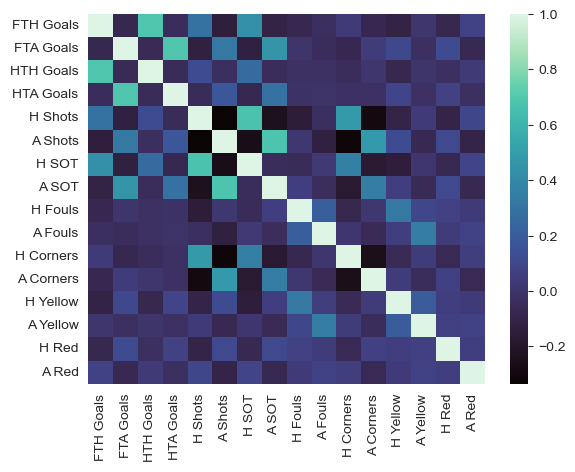

In [5]:
features = df.drop(['Season', 'HomeTeam', 'AwayTeam', 'Date', 'FT Result','HT Result', 'Display_Order', 'League', 'Referee'], axis=1)
sns.heatmap(features.corr(), annot=False, cmap='mako')

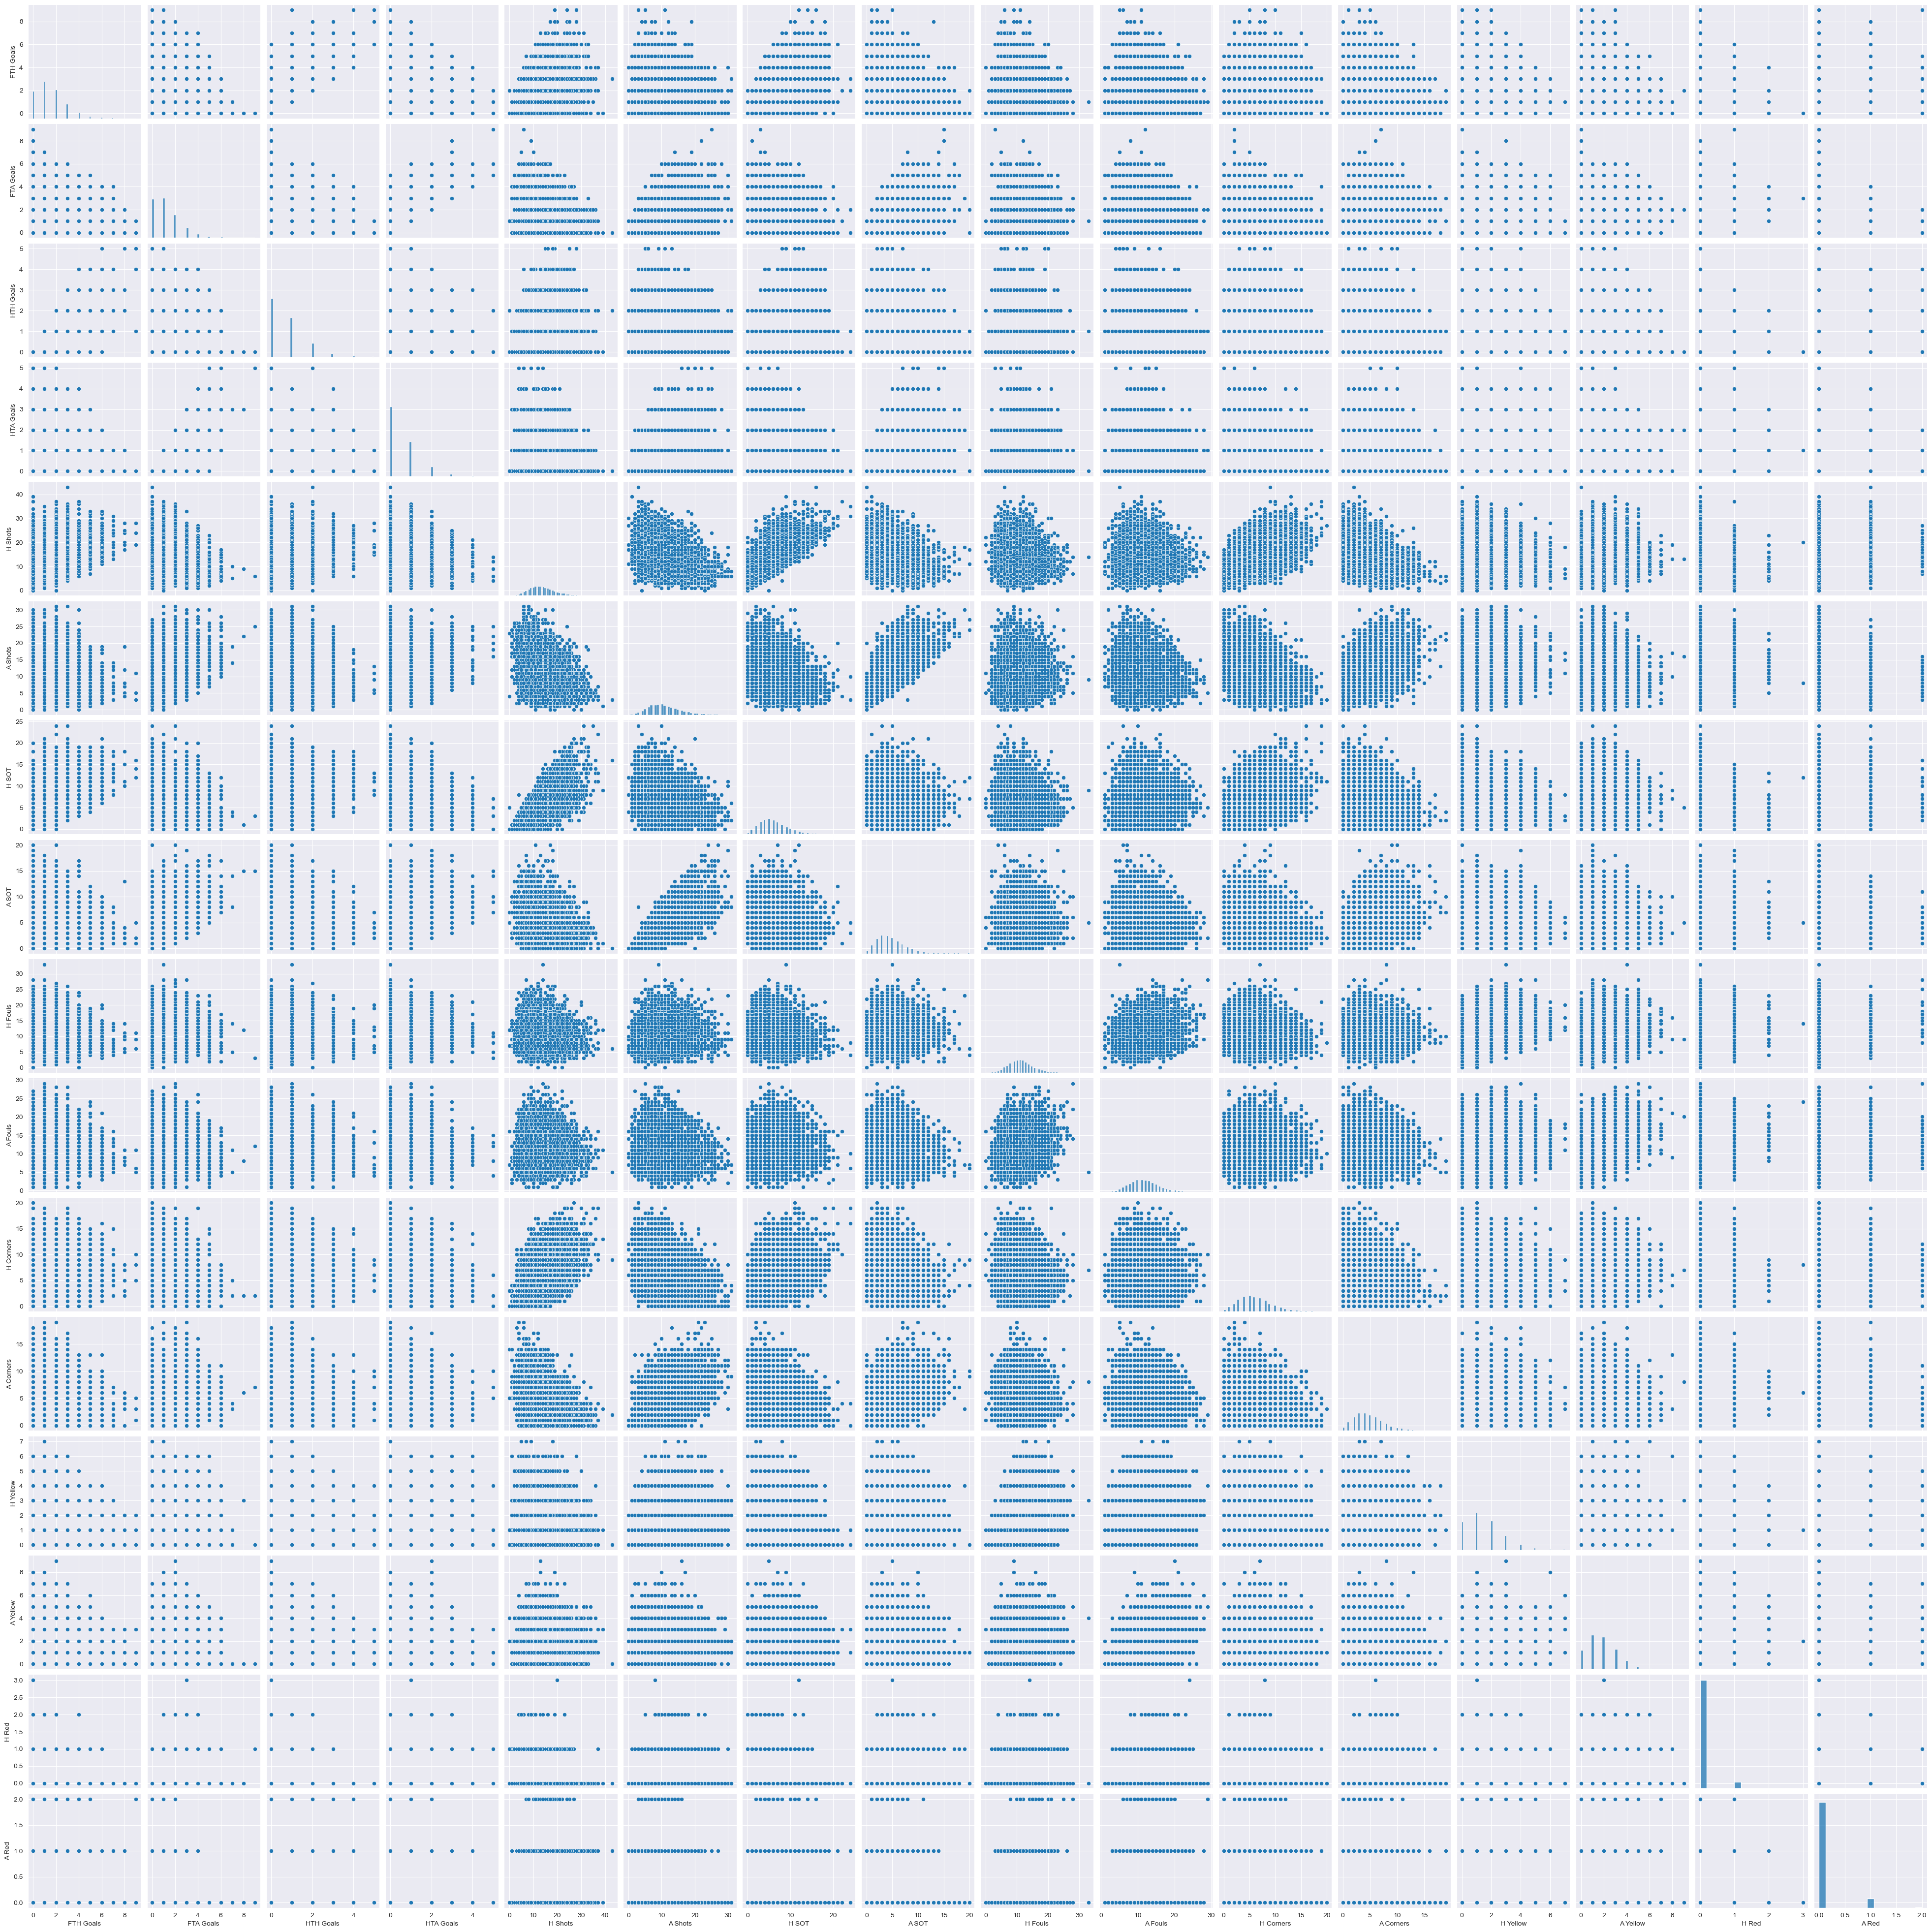

In [6]:
sns.pairplot(features)

### Summarizing total points per team per season

In [18]:
def compute_team_season_stats(df):
    teams = set(df['HomeTeam']).union(df['AwayTeam'])
    seasons = df['Season'].unique()
    team_season_stats = []

    for season in seasons:
        season_df = df[df['Season'] == season].sort_values('Date')

        for team in teams:
            team_matches = season_df[(season_df['HomeTeam'] == team) | (season_df['AwayTeam'] == team)]
            matches_played = len(team_matches)

            if matches_played == 0:
                continue

            points = goals_scored = goals_conceded = 0
            shots = shots_on_target = fouls = corners = yellow_cards = red_cards = 0
            mid_points = 0
            match_counter = 0

            for _, row in team_matches.iterrows():
                match_counter += 1

                if row['HomeTeam'] == team:
                    goals_scored += row['FTH Goals']
                    goals_conceded += row['FTA Goals']
                    shots += row['H Shots']
                    shots_on_target += row['H SOT']
                    fouls += row['H Fouls']
                    corners += row['H Corners']
                    yellow_cards += row['H Yellow']
                    red_cards += row['H Red']

                    if row['FT Result'] == 'H':
                        points += 3
                    elif row['FT Result'] == 'D':
                        points += 1

                else:
                    goals_scored += row['FTA Goals']
                    goals_conceded += row['FTH Goals']
                    shots += row['A Shots']
                    shots_on_target += row['A SOT']
                    fouls += row['A Fouls']
                    corners += row['A Corners']
                    yellow_cards += row['A Yellow']
                    red_cards += row['A Red']

                    if row['FT Result'] == 'A':
                        points += 3
                    elif row['FT Result'] == 'D':
                        points += 1

                if match_counter == 19:
                    mid_points = points

            team_season_stats.append({
                'Season': season,
                'Team': team,
                'Matches': len(team_matches),
                'Points': points,
                'Half_Season_Points': mid_points,
                'Goals_Scored': goals_scored,
                'Goals_Conceded': goals_conceded,
                'Shots': shots,
                'Shots_on_Target': shots_on_target,
                'Fouls': fouls,
                'Corners': corners,
                'Yellow_Cards': yellow_cards,
                'Red_Cards': red_cards,
            })

    return pd.DataFrame(team_season_stats)

team_season_df = compute_team_season_stats(df)
print(team_season_df.head(20))

     Season            Team  Matches  Points  Half_Season_Points  \
0   2024/25          Wolves       21      16                  15   
1   2024/25        West Ham       21      26                  26   
2   2024/25       Tottenham       21      24                  20   
3   2024/25     Bournemouth       21      34                  28   
4   2024/25         Everton       20      17                  17   
5   2024/25         Chelsea       21      37                  34   
6   2024/25       Brentford       21      28                  22   
7   2024/25       Liverpool       20      47                  44   
8   2024/25         Ipswich       21      16                  12   
9   2024/25  Crystal Palace       21      24                  20   
10  2024/25        Brighton       21      31                  29   
11  2024/25       Newcastle       21      38                  34   
12  2024/25     Southampton       21       6                   6   
13  2024/25       Leicester       21      14    

### Visualization

<Axes: >

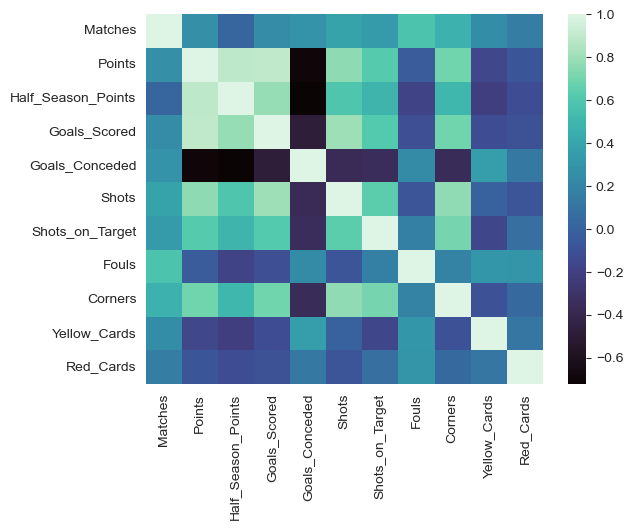

In [13]:
features = team_season_df.drop(["Season", "Team"], axis=1)
sns.heatmap(features.corr(), annot=False, cmap='mako')

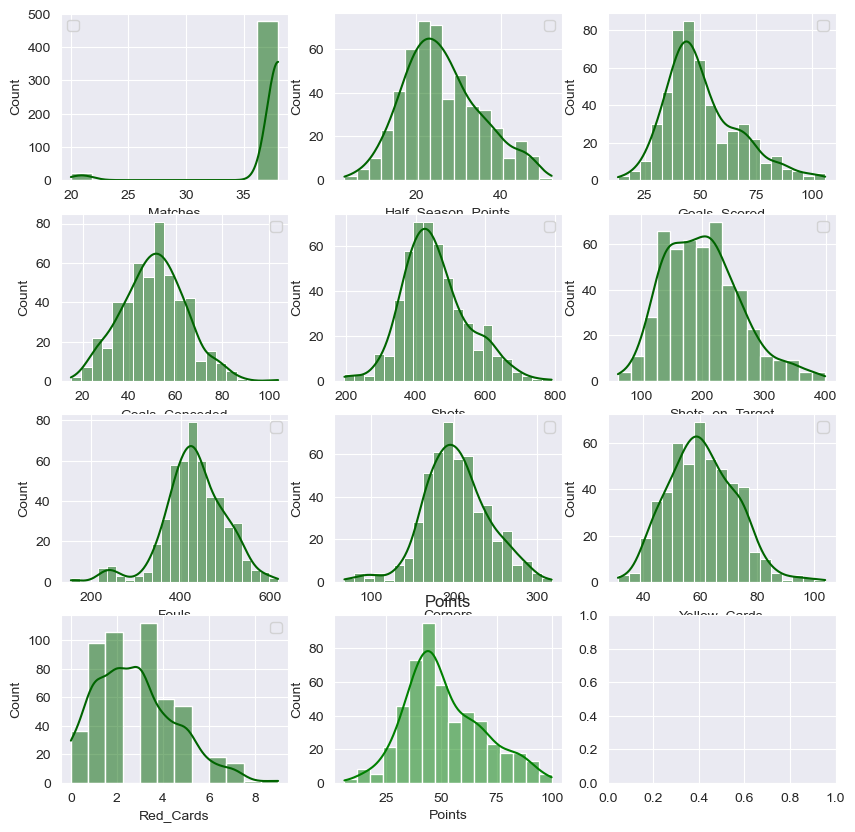

In [61]:
target=team_season_df["Points"]
input_features=team_season_df.drop(["Season", "Team", "Points"], axis=1)
feature_names=["Matches", "Half_Season_Points","Goals_Scored", "Goals_Conceded", "Shots", "Shots_on_Target", "Fouls", "Corners", "Yellow_Cards", "Red_Cards"]
fig = plt.figure(figsize=(10, 10))
fig.subplots(nrows=4, ncols=3)
for feat_i in range(input_features.shape[1]):
    ax = plt.subplot(4,3, feat_i+1)
    sns.histplot(input_features.iloc[:,feat_i],color='darkgreen',kde=True,stat="count")
    plt.legend()
ax = plt.subplot(4,3, feat_i+2)
plt.title("Points")
sns.histplot(target, color = "green", kde=True, stat="count")
plt.show()

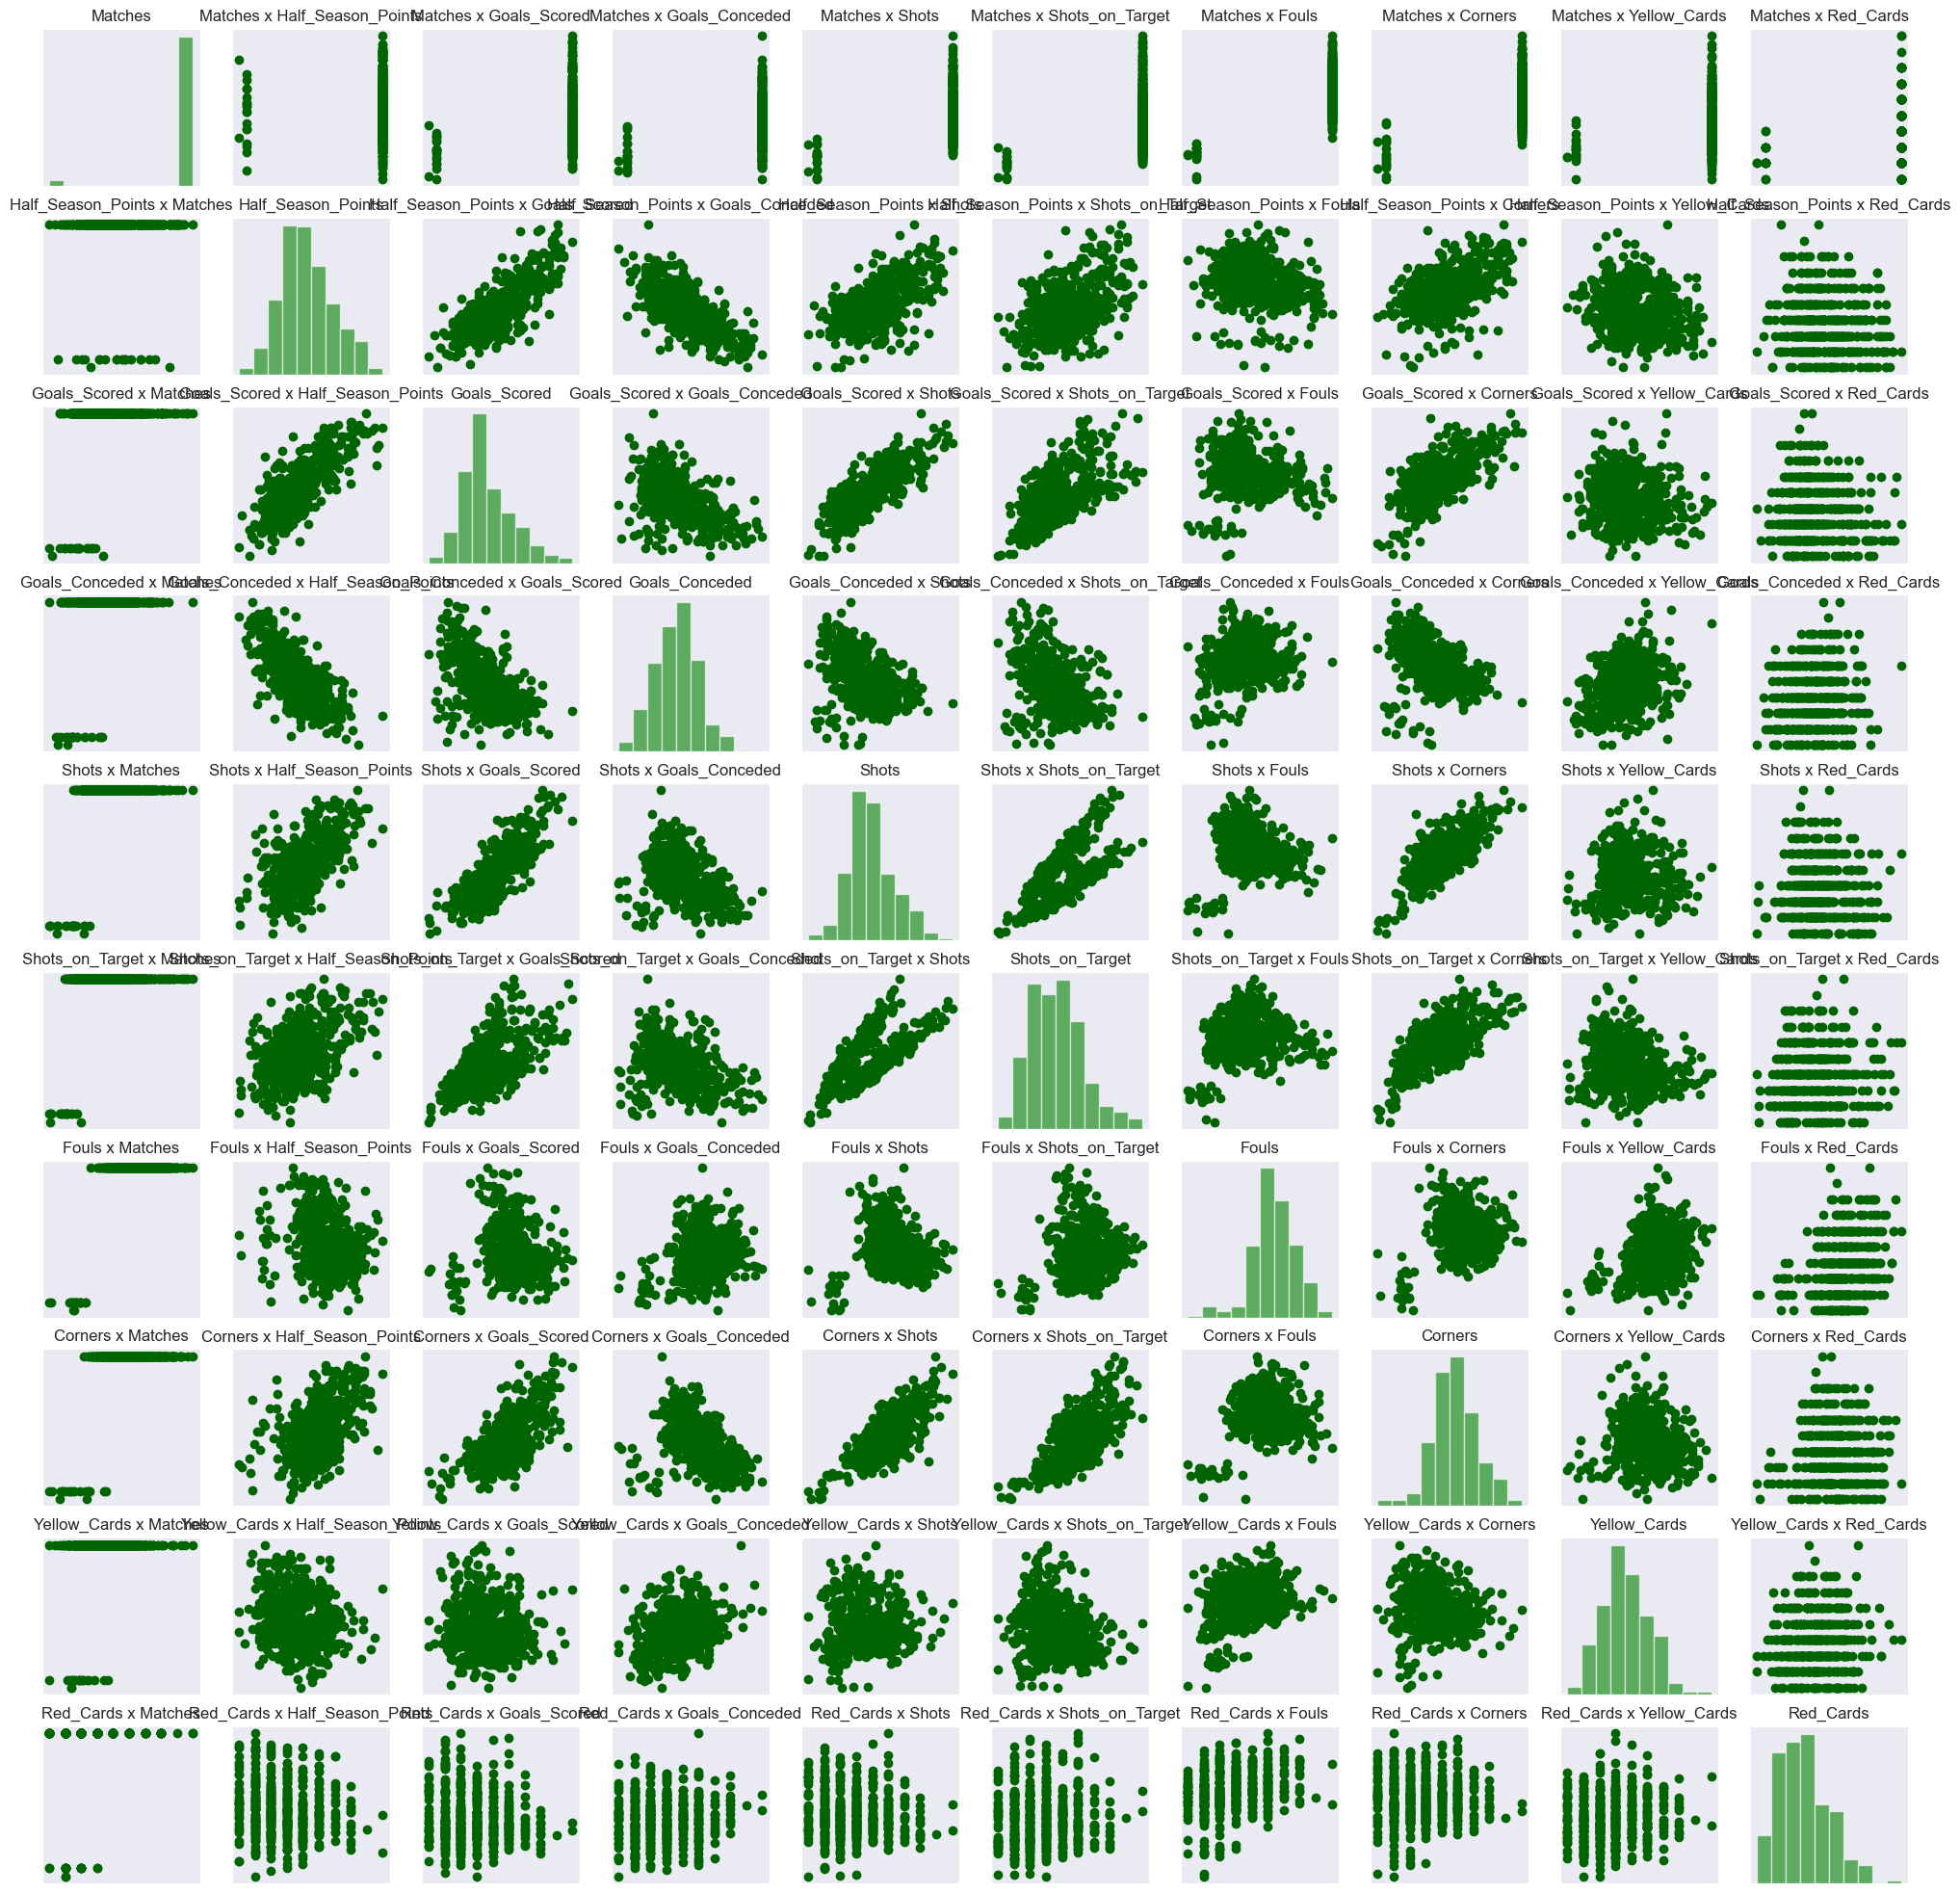

In [17]:
number_of_features = input_features.shape[1]
fig = plt.figure(figsize=(25, 25))
fig.subplots(nrows=number_of_features, ncols=number_of_features)
for feature_i in range(number_of_features):
    for feature_j in range(number_of_features):
        ax = plt.subplot(number_of_features,number_of_features,number_of_features*feature_i + feature_j+1)
        if feature_i==feature_j:
          plt.hist(input_features.iloc[:, feature_i], alpha=.6, color="green")
          plt.title(feature_names[feature_i])
        else:
          plt.scatter(input_features.iloc[:,feature_i], input_features.iloc[:,feature_j], color="darkgreen")
          plt.title(feature_names[feature_i]+" x "+feature_names[feature_j])
        plt.xticks(())
        plt.yticks(())
plt.show()

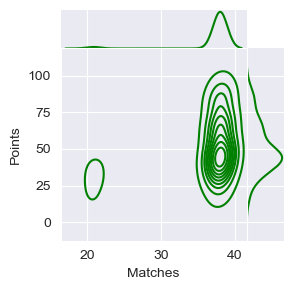

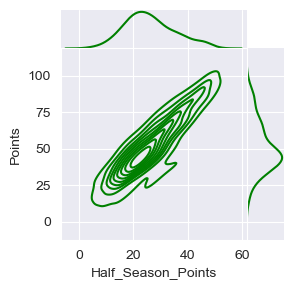

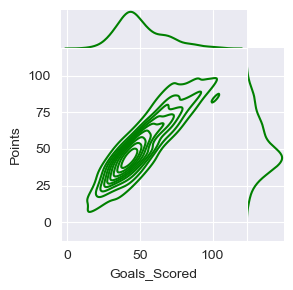

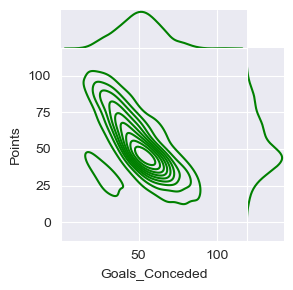

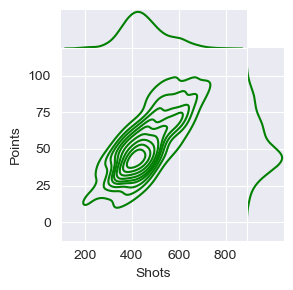

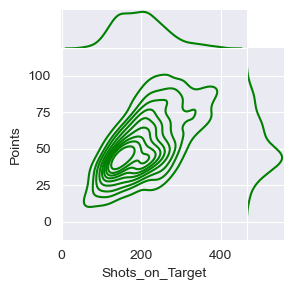

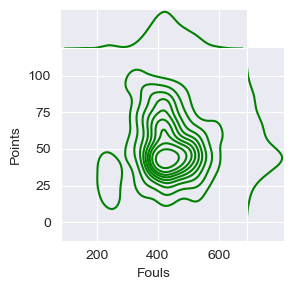

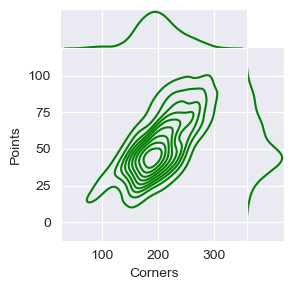

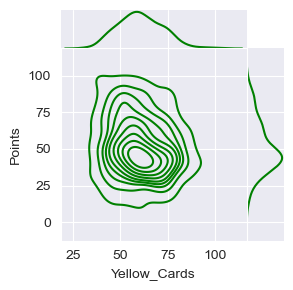

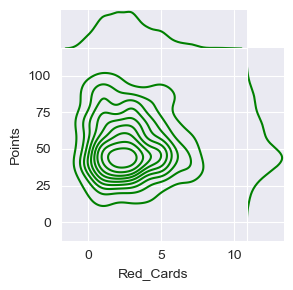

In [69]:
for feat_i in range(input_features.shape[1]):
    sns.jointplot(x=input_features.iloc[:,feat_i], y=target, kind="kde", space=0, color="g", height = 3)
plt.show()

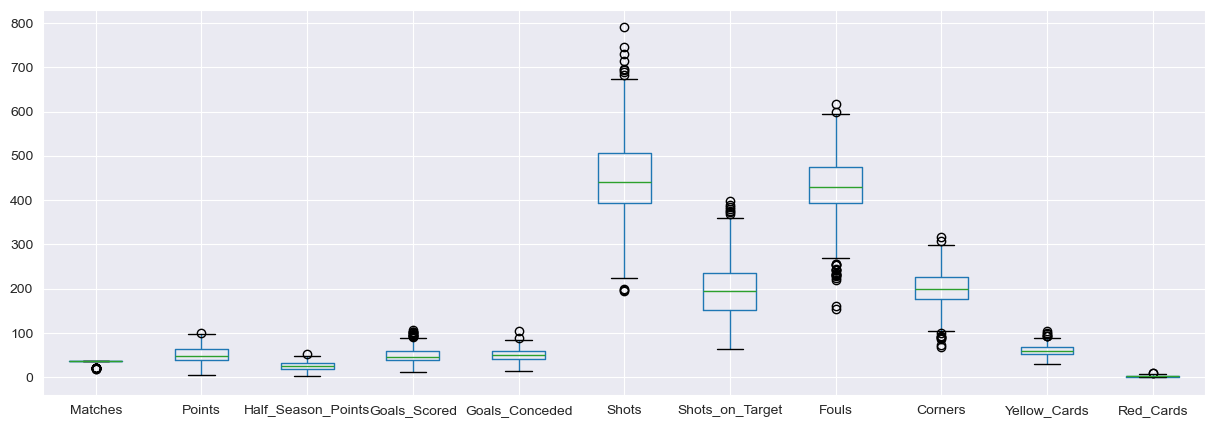

In [56]:
fig=plt.figure(figsize=(15,5))
team_season_df.boxplot()
plt.show()

# Models for Regression

In [19]:
train_df = team_season_df[team_season_df['Season']!= "2024/25"]
test_df = team_season_df[team_season_df['Season'] == "2024/25"]
X_train = train_df.drop(['Season', 'Team', 'Points'], axis=1)
y_train = train_df['Points']
X_test = test_df.drop(['Season', 'Team', 'Points'], axis=1)
y_test=[
    42,  # Wolves
    43,  # West Ham
    38,  # Tottenham
    56,  # Bournemouth
    48,  # Everton
    69,  # Chelsea
    56,  # Brentford
    84,  # Liverpool
    22,  # Ipswich
    53,  # Crystal Palace
    61,  # Brighton
    66,  # Newcastle
    12,  # Southampton
    25,  # Leicester
    65,  # Nott'm Forest
    71,  # Man City
    54,  # Fulham
    74,  # Arsenal
    42,  # Man United
    66   # Aston Villa
]

In [20]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear Regression

MSE for Linear Regression: 71.8337458409093
MAE for Linear Regression: 7.383545798168932
R2 for Linear Regression: 0.7808794386044207


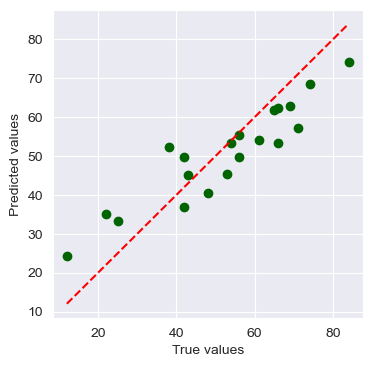

In [34]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
predictions_lr = lr.predict(X_test_scaled)
mse_lr = mean_squared_error(y_test, predictions_lr)
mae_lr = mean_absolute_error(y_test, predictions_lr)
r2_lr = r2_score(y_test, predictions_lr)
print("MSE for Linear Regression:", mse_lr)
print("MAE for Linear Regression:", mae_lr)
print("R2 for Linear Regression:", r2_lr)

y_test_arr = np.array(y_test)

plt.figure(figsize=(4, 4))
plt.scatter(y_test_arr, predictions_lr, color="darkgreen")
plt.plot([y_test_arr.min(), y_test_arr.max()], [y_test_arr.min(), y_test_arr.max()], color="red", linestyle="--")
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.show()

### Linear Ridge Regression

MSE for Linear Ridge Regression: 72.55279592447353
MAE for Linear Ridge Regression: 7.5017082822028085
R2 for Linear Ridge Regression: 0.7786860592095736


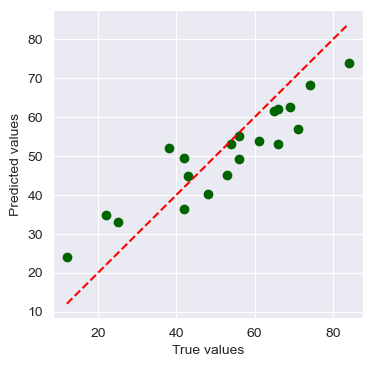

In [33]:
lr_ridge = RidgeCV()
lr_ridge.fit(X_train_scaled, y_train)
predictions_ridge = lr_ridge.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, predictions_ridge)
mae_ridge = mean_absolute_error(y_test, predictions_ridge)
r2_ridge = r2_score(y_test, predictions_ridge)
print("MSE for Linear Ridge Regression:", mse_ridge)
print("MAE for Linear Ridge Regression:", mae_ridge)
print("R2 for Linear Ridge Regression:", r2_ridge)

y_test_arr = np.array(y_test)

plt.figure(figsize=(4, 4))
plt.scatter(y_test_arr, predictions_ridge, color="darkgreen")
plt.plot([y_test_arr.min(), y_test_arr.max()], [y_test_arr.min(), y_test_arr.max()], color="red", linestyle="--")
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.show()

### Linear Lasso Regression

MSE for Linear Lasso Regression: 73.16344224820337
MAE for Linear Lasso Regression: 7.542702912795559
R2 for Linear Lasso Regression: 0.7768233529883755


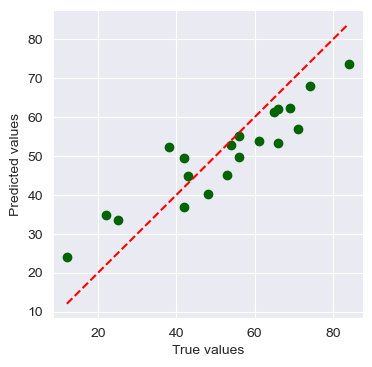

In [35]:
lr_lasso = LassoCV()
lr_lasso.fit(X_train_scaled, y_train)
predictions_lr_lasso = lr_lasso.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, predictions_lr_lasso)
mae_lasso = mean_absolute_error(y_test, predictions_lr_lasso)
r2_lasso= r2_score(y_test, predictions_lr_lasso)
print("MSE for Linear Lasso Regression:", mse_lasso)
print("MAE for Linear Lasso Regression:", mae_lasso)
print("R2 for Linear Lasso Regression:", r2_lasso)

y_test_arr = np.array(y_test)

plt.figure(figsize=(4, 4))
plt.scatter(y_test_arr, predictions_lr_lasso, color="darkgreen")
plt.plot([y_test_arr.min(), y_test_arr.max()], [y_test_arr.min(), y_test_arr.max()], color="red", linestyle="--")
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.show()

### Elastic Net Regression

MSE for Elastic Net: 89.51414921506326
MAE for Elastic Net: 8.661744187058858
R2 for Elastic Net: 0.726947406135656


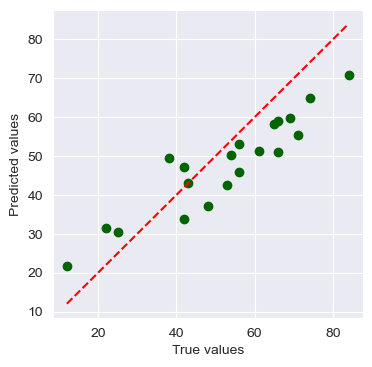

In [36]:
lr_elastic = ElasticNetCV()
lr_elastic.fit(X_train_scaled, y_train)
predictions_lr_elastic = lr_elastic.predict(X_test_scaled)
mse_elastic = mean_squared_error(y_test, predictions_lr_elastic)
mae_elastic = mean_absolute_error(y_test, predictions_lr_elastic)
r2_elastic= r2_score(y_test, predictions_lr_elastic)
print("MSE for Elastic Net:", mse_elastic)
print("MAE for Elastic Net:", mae_elastic)
print("R2 for Elastic Net:", r2_elastic)

y_test_arr = np.array(y_test)

plt.figure(figsize=(4, 4))
plt.scatter(y_test_arr, predictions_lr_elastic, color="darkgreen")
plt.plot([y_test_arr.min(), y_test_arr.max()], [y_test_arr.min(), y_test_arr.max()], color="red", linestyle="--")
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.show()

### Bayesian Regression

MSE for Bayesian Regression: 72.04077394333889
MAE for Bayesian Regression: 7.421748393404012
R2 for Bayesian Regression: 0.7802479232421353


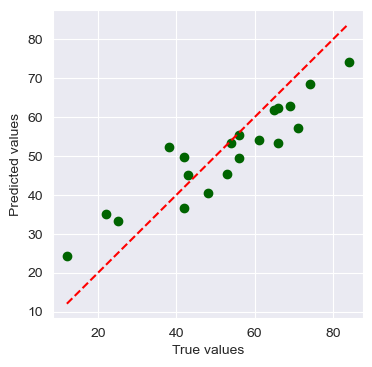

In [29]:
bayes = BayesianRidge()
bayes.fit(X_train_scaled, y_train)
predictions_bayes = bayes.predict(X_test_scaled)
mse_bayes = mean_squared_error(y_test, predictions_bayes)
mae_bayes = mean_absolute_error(y_test, predictions_bayes)
r2_bayes= r2_score(y_test, predictions_bayes)
print("MSE for Bayesian Regression:", mse_bayes)
print("MAE for Bayesian Regression:", mae_bayes)
print("R2 for Bayesian Regression:", r2_bayes)

y_test_arr = np.array(y_test)

plt.figure(figsize=(4, 4))
plt.scatter(y_test_arr, predictions_bayes, color="darkgreen")
plt.plot([y_test_arr.min(), y_test_arr.max()], [y_test_arr.min(), y_test_arr.max()], color="red", linestyle="--")
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.show()

## Support Vector Regressor

MSE for Support Vector Regressor: 68.12027713971622
MAE for Support Vector Regressor: 7.186380193915968
R2 for Support Vector Regressor: 0.7922069468250339
Best Params: {'svr__C': 10, 'svr__epsilon': 5, 'svr__gamma': 'scale', 'svr__kernel': 'linear'}


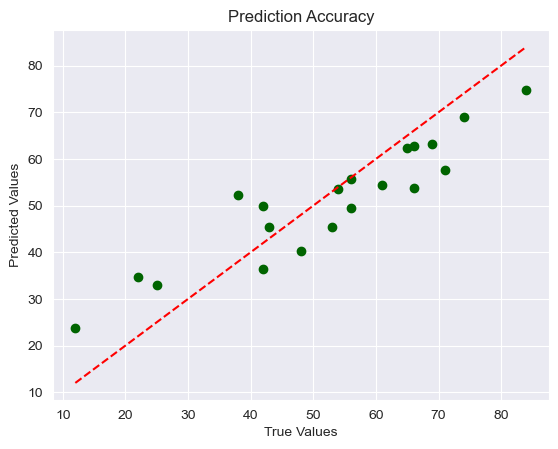

In [37]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_grid = {
    'svr__C': [0.1, 1, 10, 100, 500],
    'svr__epsilon': [0.01, 0.1, 1, 5],
    'svr__gamma': ['scale', 'auto'],
    'svr__kernel': ['rbf', 'linear' , 'poly']
}


grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

best_svr = grid.best_estimator_

predictions_svr = best_svr.predict(X_test)
mse_svr = mean_squared_error(y_test, predictions_svr)
mae_svr = mean_absolute_error(y_test, predictions_svr)
r2_svr= r2_score(y_test, predictions_svr)
print("MSE for Support Vector Regressor:", mse_svr)
print("MAE for Support Vector Regressor:", mae_svr)
print("R2 for Support Vector Regressor:", r2_svr)

print("Best Params:", grid.best_params_)

plt.scatter(y_test, predictions_svr, color="darkgreen")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Prediction Accuracy")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--")
plt.show()

## Foundational Models

### Decision Tree Regressor

MSE for Decision Tree Regressor: 205.4555929511095
MAE for Decision Tree Regressor: 12.828667007811031
R2 for Decision Tree Regressor: 0.37328139661526405
Best Params: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}


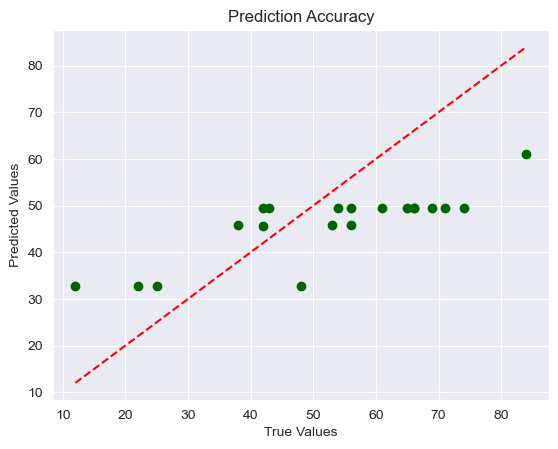

In [38]:
param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion':['squared_error', 'friedman_mse', 'absolute_error', 'poisson']
}

grid = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid,cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

best_dt = grid.best_estimator_

predictions_dt = best_dt.predict(X_test)
mse_dt = mean_squared_error(y_test, predictions_dt)
mae_dt = mean_absolute_error(y_test, predictions_dt)
r2_dt= r2_score(y_test, predictions_dt)
print("MSE for Decision Tree Regressor:", mse_dt)
print("MAE for Decision Tree Regressor:", mae_dt)
print("R2 for Decision Tree Regressor:", r2_dt)
print("Best Params:", grid.best_params_)

plt.scatter(y_test, predictions_dt, color="darkgreen")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Prediction Accuracy")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--")
plt.show()

### Random Forest Regressor

MSE for Random Forest Regressor: 151.07440976014493
MAE for Random Forest Regressor: 11.090452579365074
R2 for Random Forest Regressor: 0.5391649274080272
Best Params: {'criterion': 'friedman_mse', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}


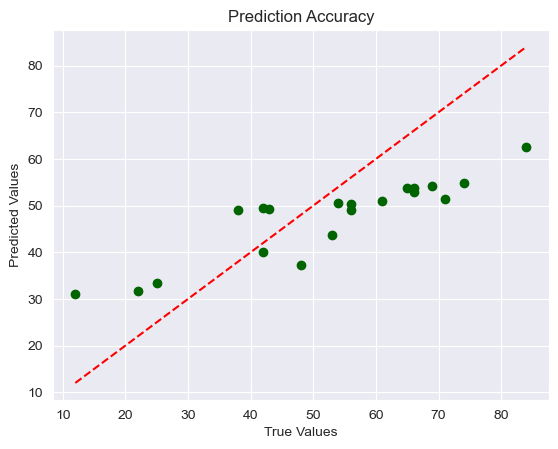

In [45]:
param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion':['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

predictions_rf = best_rf.predict(X_test)
mse_rf = mean_squared_error(y_test, predictions_rf)
mae_rf = mean_absolute_error(y_test, predictions_rf)
r2_rf= r2_score(y_test, predictions_rf)
print("MSE for Random Forest Regressor:", mse_rf)
print("MAE for Random Forest Regressor:", mae_rf)
print("R2 for Random Forest Regressor:", r2_rf)
print("Best Params:", grid.best_params_)

plt.scatter(y_test, predictions_rf, color="darkgreen")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Prediction Accuracy")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--")
plt.show()

### Neural Network for Regression

In [52]:
y_train_array = np.array(y_train).reshape(-1, 1)
y_test_array = np.array(y_test).reshape(-1, 1)

y_train_scaled = scaler.fit_transform(y_train_array)
y_test_scaled = scaler.transform(y_test_array)
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
nn_model.compile(optimizer='adam', loss='mse')
history = nn_model.fit(X_train_scaled, y_train_scaled, epochs=300, batch_size=4, validation_split=0.2, verbose=0)
predictions_nn = nn_model.predict(X_test_scaled).flatten()

predictions_nn_unscaled = scaler.inverse_transform(predictions_nn.reshape(-1, 1)).flatten()
mse_nn = mean_squared_error(y_test, predictions_nn_unscaled)
mae_nn = mean_absolute_error(y_test, predictions_nn_unscaled)
r2_nn = r2_score(y_test, predictions_nn_unscaled)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


MSE for Neural Network: 287.83140771085164
MAE for Neural Network: 14.588323593139648
R2 for Neural Network: 0.12200361490249634


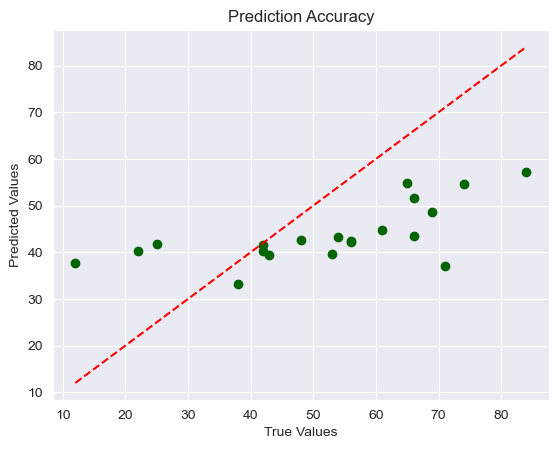

In [66]:
print("MSE for Neural Network:", mse_nn)
print("MAE for Neural Network:", mae_nn)
print("R2 for Neural Network:", r2_nn)

plt.scatter(y_test, predictions_nn_unscaled, color="darkgreen")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Prediction Accuracy")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--")
plt.show()

# Comparison

In [63]:
comparison_df = test_df[['Team']].copy()
comparison_df['Real Points'] = y_test
comparison_df['LR_Pred'] = predictions_lr
comparison_df['LR_Ridge_Pred'] = predictions_ridge
comparison_df['LR_Lasso_Pred'] = predictions_lr_lasso
comparison_df['LR_ElasticNet_Pred'] = predictions_lr_elastic
comparison_df['Bayesian_Pred'] = predictions_bayes
comparison_df['SVR_Pred'] = predictions_svr
comparison_df['DT_Pred'] = predictions_dt
comparison_df['RF_Pred'] = predictions_rf
comparison_df['NN_Pred'] = predictions_nn

comparison_df['Avg_Pred'] = comparison_df[['LR_Pred', 'RF_Pred', 'NN_Pred', 'DT_Pred', 'LR_Ridge_Pred', 'LR_Lasso_Pred', 'LR_ElasticNet_Pred', 'SVR_Pred', 'Bayesian_Pred']].mean(axis=1)

comparison_df = comparison_df.sort_values('Real Points', ascending=False)

print(tabulate(comparison_df.head(20), headers='keys', tablefmt='pretty'))

+----+----------------+-------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------------+--------------------+
|    |      Team      | Real Points |      LR_Pred       |   LR_Ridge_Pred    |   LR_Lasso_Pred    | LR_ElasticNet_Pred |   Bayesian_Pred    |      SVR_Pred      |      DT_Pred       |      RF_Pred       |       NN_Pred       |      Avg_Pred      |
+----+----------------+-------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------------+--------------------+
| 7  |   Liverpool    |     84      |  74.1250518042385  | 73.84019582978415  | 73.72952564197328  |  70.8775265012926  | 74.03333195172719  | 74.73864098653675  | 61.142857142857146 | 62.60361904761905  | 0.5195547342300415  | 62.84558929336208  |
| 17

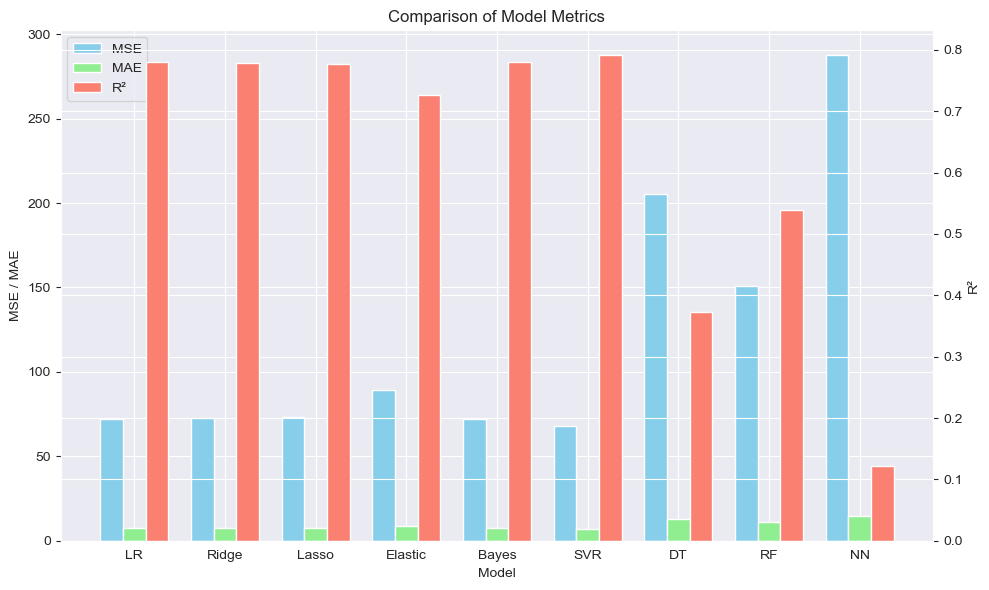

In [65]:
models = ['LR', 'Ridge', 'Lasso', 'Elastic', 'Bayes', 'SVR', 'DT', 'RF', 'NN']

mse_values = [mse_lr, mse_ridge, mse_lasso, mse_elastic, mse_bayes, mse_svr, mse_dt, mse_rf, mse_nn]
mae_values = [mae_lr, mae_ridge, mae_lasso, mae_elastic, mae_bayes, mae_svr, mae_dt, mae_rf, mae_nn]
r2_values  = [r2_lr, r2_ridge, r2_lasso, r2_elastic, r2_bayes, r2_svr, r2_dt, r2_rf, r2_nn]

x = np.arange(len(models))
width = 0.25

fig, ax1 = plt.subplots(figsize=(10, 6))

mse_bar = ax1.bar(x - width, mse_values, width, label='MSE', color='skyblue')
mae_bar = ax1.bar(x, mae_values, width, label='MAE', color='lightgreen')

ax2 = ax1.twinx()
r2_bar = ax2.bar(x + width, r2_values, width, label='R²', color='salmon')

ax1.set_xlabel('Model')
ax1.set_ylabel('MSE / MAE')
ax2.set_ylabel('R²')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_title('Comparison of Model Metrics')

bars = [mse_bar, mae_bar, r2_bar]
labels = ['MSE', 'MAE', 'R²']
ax1.legend(bars, labels, loc='upper left')

plt.tight_layout()
plt.show()
